In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import climattr as eea

plt.rcParams.update({'font.size': 14})

In [11]:
df = pd.read_csv('data/model_input_mexico-peru-brazil_immunity_city.csv', parse_dates=['date_first_symptoms'])
df['year'] = df['date_first_symptoms'].dt.year
df['year'][df['country'] == 'Brazil'] = df[df['country'].isin(['Brazil', 'Peru'])]['date_first_symptoms'].apply(lambda x: x.year + 1 if x.month >= 8 else x.year)

df_mexico = df[(df['country'] == 'Mexico') & (df['year'] == 2024)].copy()

df_mexico = df_mexico.groupby(['region', 'city_residency', 'date_first_symptoms']).agg({'n_cases': 'sum', 'population': 'sum'}).reset_index()
df_mexico = df_mexico.groupby(['region', 'city_residency']).agg({'n_cases': 'sum', 'population': 'mean'}).reset_index()
df_mexico['dengue_inc'] = df_mexico['n_cases'] / df_mexico['population'] * 100000

gdf = gpd.read_file("utils/muni_2012gw/Muni_2012gw.shp")

gdf['CVE_ENT'] = gdf['CVE_ENT'].astype(str).str.zfill(2)
gdf['CVE_MUN'] = gdf['CVE_MUN'].astype(str).str.zfill(3)

gdf['municipio'] = gdf['CVE_ENT'] + '_' + gdf['CVE_MUN']

alt = pd.read_csv('utils/altitude.csv')
gdf = eea.impacts.geolocate_dataframe(alt, gdf, 'city_residency', 'municipio')
gdf['region'] = 'Below 1000 m'
gdf['region'][gdf['altitude'] >= 1000] = 'Above 1000 m'

gdf_mexico = eea.impacts.geolocate_dataframe(df_mexico, gdf[['geometry', 'city_residency']], 'city_residency', 'city_residency')
region_mexico_agg = gdf.dissolve(by='region')


/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_57569/3649160133.py:1: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/model_input_mexico-peru-brazil_immunity_city.csv', parse_dates=['date_first_symptoms'])
/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_57569/3649160133.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure

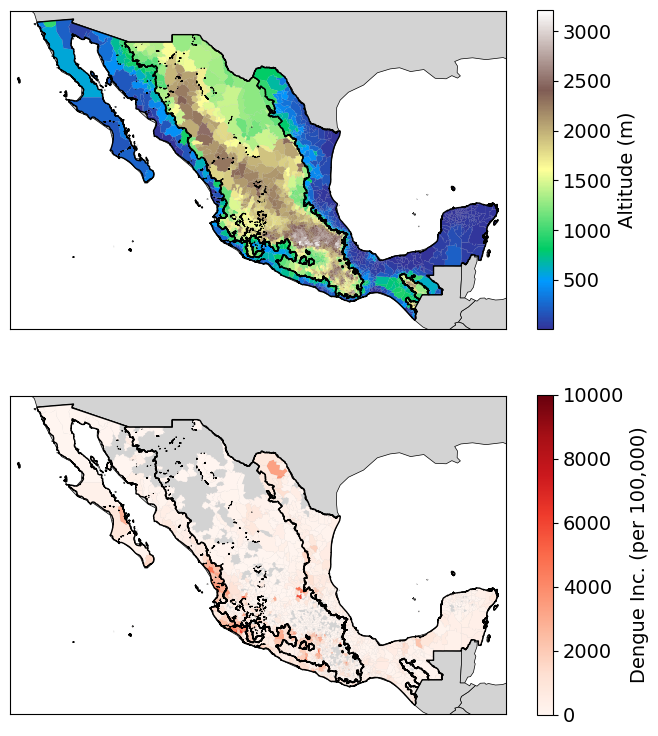

In [38]:
plt.rcParams.update({'font.size': 14})

fig, [ax2, ax1] = plt.subplots(2, 1, figsize=(8, 10), gridspec_kw={'hspace': 0.0})

# Define normalization and colormap
vmin, vmax = 0, 10000
cmap = cm.Reds
norm = colors.Normalize(vmin=vmin, vmax=vmax)

world = gpd.read_file('utils/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp')

world.plot(ax=ax1, color='lightgrey', edgecolor='black', lw=0.5)
gdf_mexico.plot(column='dengue_inc', cmap='Reds', ax=ax1, legend=True, vmin=0, vmax=10000, legend_kwds={'label': "Dengue Inc. (per 100,000)", 'shrink': 0.83})
region_mexico_agg.plot(ax=ax1, color='none', edgecolor='black')

xmin = gdf_mexico['geometry'].bounds['minx'].min()
xmax = gdf_mexico['geometry'].bounds['maxx'].max()
ymin = gdf_mexico['geometry'].bounds['miny'].min()
ymax = gdf_mexico['geometry'].bounds['maxy'].max()

ax1.set_xlim([xmin - 0.5, xmax + 0.5])
ax1.set_ylim([ymin - 0.5, ymax + 0.5])

world.plot(ax=ax2, color='lightgrey', edgecolor='black', lw=0.5)
gdf.plot(column='altitude', ax=ax2, cmap='terrain', legend=True, legend_kwds={'label': "Altitude (m)", 'shrink': 0.83})
region_mexico_agg.plot(ax=ax2, color='none', edgecolor='black')

xmin = gdf_mexico['geometry'].bounds['minx'].min()
xmax = gdf_mexico['geometry'].bounds['maxx'].max()
ymin = gdf_mexico['geometry'].bounds['miny'].min()
ymax = gdf_mexico['geometry'].bounds['maxy'].max()

ax2.set_xlim([xmin - 0.5, xmax + 0.5])
ax2.set_ylim([ymin - 0.5, ymax + 0.5])


ax1.set_xticks([])
ax1.set_yticks([])
ax2.set_xticks([])
ax2.set_yticks([])

plt.savefig('img/mexico_map.pdf', bbox_inches='tight', dpi=300)

/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_81669/2951637679.py:4: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  obs = pd.read_csv('data/model_input_mexico-peru-brazil_immunity_city.csv', parse_dates=['date_first_symptoms'])


35.56279928065929
Above 1000 m
36.307497511348444
527.3726619009209
-13.808394567427559
59.081290404069875
Below 1000 m
64.736097413911
79.32460919395544
-0.24692270057526522


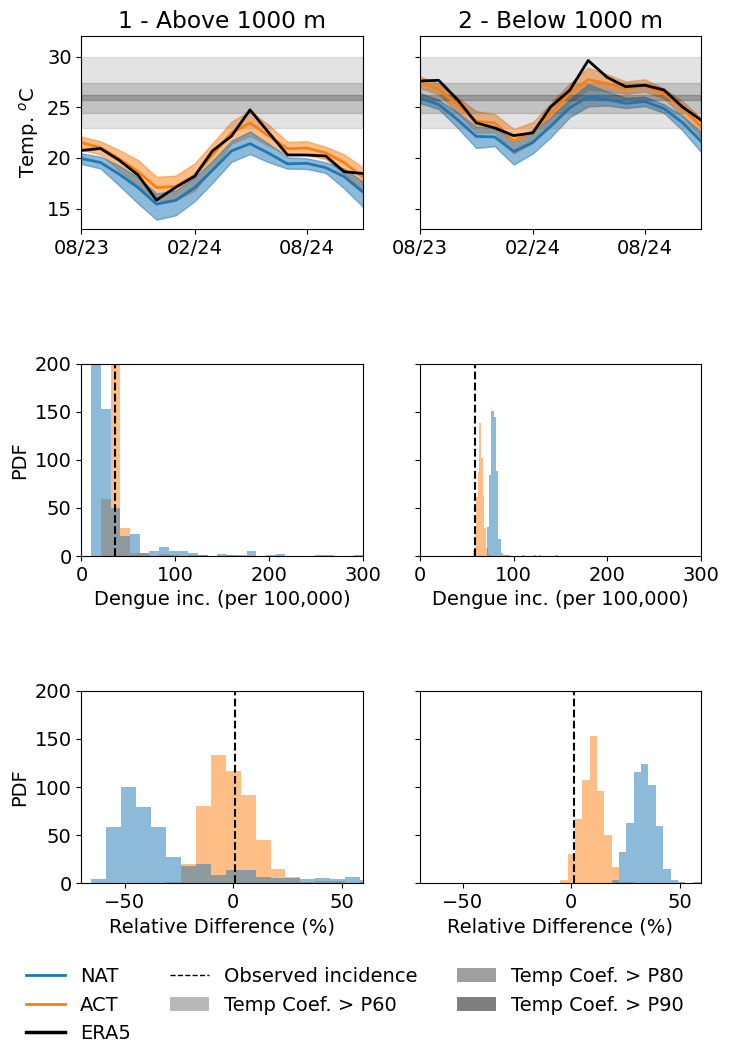

In [5]:
ext = pd.read_csv('data/ext_temp_average_region.csv', parse_dates=['date_first_symptoms']).rename({'date_first_symptoms': 'time', 'mean_2m_air_temp_degree1': 'tas'}, axis=1)
nat = pd.read_csv('data/nat_temp_average_region.csv', parse_dates=['date_first_symptoms']).rename({'date_first_symptoms': 'time', 'mean_2m_air_temp_degree1': 'tas'}, axis=1)

obs = pd.read_csv('data/model_input_mexico-peru-brazil_immunity_city.csv', parse_dates=['date_first_symptoms'])
obs = obs.groupby(['region', 'date_first_symptoms']).mean(numeric_only=True).reset_index()

ext['time'] = ext['time'].apply(lambda x: pd.to_datetime(x.strftime('%Y-%m-01')))
nat['time'] = nat['time'].apply(lambda x: pd.to_datetime(x.strftime('%Y-%m-01')))

regions = [
    'Above 1000 m', 'Below 1000 m'
]

fig, axarr = plt.subplots(3, 2, figsize=(8, 11))
plt.subplots_adjust(wspace=0.2, hspace=0.7)

for i, (region, ax) in enumerate(zip(regions, axarr[0].flatten())):
    ext_subset = ext[ext['region'] == region]
    nat_subset = nat[nat['region'] == region]

    ext_quantiles = ext_subset.groupby('time').quantile([0.025, 0.5, 0.975], numeric_only=True).reset_index()
    nat_quantiles = nat_subset.groupby('time').quantile([0.025, 0.5, 0.975], numeric_only=True).reset_index()

    ax.fill_between(
        ext_quantiles[ext_quantiles['level_1'] == 0.5]['time'],
        ext_quantiles[ext_quantiles['level_1'] == 0.025]['tas'],
        ext_quantiles[ext_quantiles['level_1'] == 0.975]['tas'],
        color='C1', alpha=0.5
    )
    ax.plot(
        ext_quantiles[ext_quantiles['level_1'] == 0.5]['time'], 
        ext_quantiles[ext_quantiles['level_1'] == 0.5]['tas'],
        color='C1', lw=2
    )

    ax.fill_between(
        nat_quantiles[nat_quantiles['level_1'] == 0.5]['time'],
        nat_quantiles[nat_quantiles['level_1'] == 0.025]['tas'],
        nat_quantiles[nat_quantiles['level_1'] == 0.975]['tas'],
        color='C0', alpha=0.5
    )
    ax.plot(
        nat_quantiles[nat_quantiles['level_1'] == 0.5]['time'], 
        nat_quantiles[nat_quantiles['level_1'] == 0.5]['tas'],
        color='C0', lw=2
    )

    ax.plot(
        obs[obs['region'] == region]['date_first_symptoms'],
        obs[obs['region'] == region]['mean_2m_air_temp_degree1'],
        color='k', lw=2
    )

    ax.set_title(f'{i+1} - {region}')
    ax.set_xlim(ext_subset['time'].min(), ext_subset['time'].max())
    ax.set_xticks(
        pd.date_range(ext_subset['time'].min(), ext_subset['time'].max(), freq='6MS')
    )
    ax.set_xticklabels(
        pd.date_range(ext_subset['time'].min(), ext_subset['time'].max(), freq='6MS').strftime('%m/%y')
    )

    spans = [
        [0.6, 22.9, 30, '#737373'],
        [0.8, 24.4, 27.4, '#404040'],
        [0.9, 25.7, 26.2, '#000000']
    ]
 
    for span in spans:
        ax.axhspan(span[1], span[2], color=span[3], alpha=0.2)

    ax.set_ylim([13, 32])


### predicted cases
ext = pd.read_csv('data/all_mexico-peru-bs_dengue_ensemble_predictions.csv', parse_dates=['date_first_symptoms'])
nat = pd.read_csv('data/nat_mexico-peru-bs_dengue_ensemble_predictions.csv', parse_dates=['date_first_symptoms'])

ext_mexico = ext[ext['region'].isin(['Above 1000 m', 'Below 1000 m']) & (ext['date_first_symptoms'] >= '2024-01-01')]
nat_mexico = nat[nat['region'].isin(['Above 1000 m', 'Below 1000 m']) & (nat['date_first_symptoms'] >= '2024-01-01')]

ext_peru = ext[ext['region'].isin(['Costa', 'Sierra', 'Selva'])]
nat_peru = nat[nat['region'].isin(['Costa', 'Sierra', 'Selva'])]

ext = pd.concat([ext_mexico, ext_peru])
nat = pd.concat([nat_mexico, nat_peru])

ext['predicted_incidence'] = ext['predicted_incidence'] * ext['total_population'] / 1e5
nat['predicted_incidence'] = nat['predicted_incidence'] * nat['total_population'] / 1e5

ext = ext.groupby(['region', 'file_number']).agg({'predicted_incidence': 'sum', 'total_population': 'sum'}).reset_index()
nat = nat.groupby(['region', 'file_number']).agg({'predicted_incidence': 'sum', 'total_population': 'sum'}).reset_index()

ext['predicted_incidence'] = 1e5 * ext['predicted_incidence'] / ext['total_population']
nat['predicted_incidence'] = 1e5 * nat['predicted_incidence'] / nat['total_population']

# fitted
fit = pd.read_csv('data/all_dengue_regional_aggregation.csv', parse_dates=['date_first_symptoms'])
fit_mexico = fit[(fit['date_first_symptoms'] >= '2024-01-01') & (fit['region'].isin(['Above 1000 m', 'Below 1000 m']))]
fit_peru = fit[(fit['date_first_symptoms'] >= '2023-08-01') & (fit['region'].isin(['Costa', 'Sierra', 'Selva']))]
fit = pd.concat([fit_mexico, fit_peru])

fit = fit.groupby('region').agg({'total_population': 'sum', 'total_pred_cases': 'sum', 'total_actual_cases': 'sum'})
fit['pred_incidence'] = 100000 * fit['total_pred_cases'] / fit['total_population']
fit['actual_incidence'] = 100000 * fit['total_actual_cases'] / fit['total_population']

for ax, region in zip(axarr[2], regions):    
    act_region = fit.loc[region, 'actual_incidence']
    print(act_region)

    if region in ['Above 1000 m']:
        bins = np.linspace(-100, 100, 30)
    elif region in ['Below 1000 m']:
        bins = np.linspace(-100, 100, 60)

    ax.hist(100 * (ext[ext['region'] == region]['predicted_incidence'] - act_region) / act_region, color='C1', alpha=0.5, bins=bins)
    ax.hist(100 * (nat[nat['region'] == region]['predicted_incidence'] - act_region) / act_region, color='C0', alpha=0.5, bins=bins)

    print(region)
    print(ext[ext['region'] == region]['predicted_incidence'].mean())
    print(nat[nat['region'] == region]['predicted_incidence'].mean())
    print((ext[ext['region'] == region]['predicted_incidence'] / act_region).mean() - (nat[nat['region'] == region]['predicted_incidence'] / act_region).mean())

    ax.axvline(1, color='k', ls='--')
    ax.set_xlabel('Relative Difference (%)')
    ax.set_ylim([0, 200])
    ax.set_xlim([-70, 60])


for ax, region in zip(axarr[1], regions):    
    act_region = fit.loc[region, 'actual_incidence']

    if region in ['Above 1000 m']:
        bins1 = np.linspace(0, 300, 30)
        bins2 = np.linspace(0, 300, 30)
    elif region in ['Below 1000 m']:
        bins1 = 10
        bins2 = 30
    else:
        bins1 = 10
        bins2 = 10

    ax.hist(ext[ext['region'] == region]['predicted_incidence'], color='C1', alpha=0.5, bins=bins1)
    ax.hist(nat[nat['region'] == region]['predicted_incidence'], color='C0', alpha=0.5, bins=bins2)

    ax.axvline(act_region, color='k', ls='--')
    ax.set_xlabel('Dengue inc. (per 100,000)')
    ax.set_xlim([0, 300])
    ax.set_ylim([0, 200])

axarr[0, 0].set_ylabel(r'Temp. $^o$C')
axarr[1, 0].set_ylabel('PDF')
axarr[2, 0].set_ylabel('PDF')

axarr[0, 1].set_yticklabels([])
axarr[1, 1].set_yticklabels([])
axarr[2, 1].set_yticklabels([])

legend_elements = []

legend_elements.append(Line2D([0], [0], color='C0', lw=2, label='NAT'))
legend_elements.append(Line2D([0], [0], color='C1', lw=2, label='ACT'))
legend_elements.append(Line2D([0], [0], color='k', lw=2.5, label='ERA5'))
legend_elements.append(Line2D([0], [0], color='k', ls='--', lw=1, label='Observed incidence'))
legend_elements.append(Patch(facecolor='#737373', alpha=0.5, label='Temp Coef. > P60'))
legend_elements.append(Patch(facecolor='#404040', alpha=0.5, label='Temp Coef. > P80'))
legend_elements.append(Patch(facecolor='#000000', alpha=0.5, label='Temp Coef. > P90'))

# Place legend on the figure level or first axis
fig.legend(handles=legend_elements, frameon=False, ncol=3, bbox_to_anchor=(0.9, 0.05))
plt.savefig('img/figures_mexico_cases.pdf', bbox_inches='tight')